In [2]:
import pandas as pd
import numpy as np
import h5py
from tqdm import tqdm
from pyhdf.SD import SD, SDC # <--- 导入 pyhdf 库
# ==============================================================================
# 1. 配置参数
# ==============================================================================

# --- 输入文件 ---
# 您之前匹配好的、包含原始I,Q,U等特征的数据集
INPUT_CSV_PATH = '/media/amers/SSD_part1/DPC_project/Deep_learning_retrieval/DPC_ML_Datasetv6/DPC_combined_with_Surface_60percent.csv' 

# 全球地表类型HDF文件
#LANDCOVER_HDF_PATH = '/media/amers/WHX/land_cover/MCD12C1.A2023001.061.2024251212901.hdf' 

# --- 输出文件 ---
OUTPUT_ENHANCED_CSV_PATH = 'DPC_prior_dataset.csv'

# ==============================================================================
# 2. 地表类型提取函数
# ==============================================================================




# ==============================================================================
# 3. 特征工程函数 (与之前一致)
# ==============================================================================

def perform_feature_engineering(df):
    """对输入的DataFrame执行所有必要的特征工程步骤，并返回增强后的DataFrame"""
    print("\n开始进行特征工程...")
    df_processed = df.copy()

    # --- A. 计算散射角 ---
    for i in tqdm(range(2, 14), desc="计算散射角"):
        sza_rad = np.deg2rad(df_processed[f'sza_ang{i}'])
        vza_rad = np.deg2rad(df_processed[f'vza_ang{i}'])
        phi_rad = np.deg2rad(df_processed[f'phi_ang{i}'])
        cos_scat_ang = -np.cos(sza_rad) * np.cos(vza_rad) - np.sin(sza_rad) * np.sin(vza_rad) * np.cos(phi_rad)
        df_processed[f'scat_ang_{i}'] = np.rad2deg(np.arccos(np.clip(cos_scat_ang, -1.0, 1.0)))

    # --- B. 计算DolP和TOA ---
    polarization_bands = ['490', '670', '865']
    all_bands = ['443', '490', '565', '670', '865']
    for band in tqdm(all_bands, desc="计算TOA和DolP"):
        for i in range(2, 14):
            # 检查列是否存在
            i_col = f'I{band}_ang{i}'
            if i_col not in df_processed.columns: continue

            I = df_processed[i_col]
            TOA = np.zeros_like(I)
            valid_mask = I > 0
            TOA[valid_mask] = I[valid_mask] / np.cos(np.deg2rad(df_processed[f'sza_ang{i}'][valid_mask]))
            df_processed[f'TOA{band}_ang{i}'] = TOA
            
            if band in polarization_bands:
                q_col, u_col = f'Q{band}_ang{i}', f'U{band}_ang{i}'
                if q_col not in df_processed.columns or u_col not in df_processed.columns: continue
                
                Q = df_processed[q_col]
                U = df_processed[u_col]
                dolp = np.zeros_like(I)
                dolp[valid_mask] = np.sqrt(Q[valid_mask]**2 + U[valid_mask]**2) / I[valid_mask]
                df_processed[f'DolP{band}_ang{i}'] = dolp

    print("特征工程完成。")
    return df_processed

# ==============================================================================
# 4. 主执行流程
# ==============================================================================
if __name__ == '__main__':
    # --- 加载原始匹配数据 ---
    try:
        print(f"--- 正在加载原始匹配数据集: {INPUT_CSV_PATH} ---")
        original_data = pd.read_csv(INPUT_CSV_PATH)
        # 先进行一次简单的清理
        original_data.dropna(subset=['lat', 'lon'], inplace=True)
        print(f"加载成功！原始形状: {original_data.shape}")
    except FileNotFoundError:
        print(f"错误：找不到原始匹配数据集 '{INPUT_CSV_PATH}'！"); exit()




    # --- 步骤 2: 执行特征转换 (计算TOA, DolP等) ---
    # 我们在完整的原始数据上进行计算
    enhanced_data = perform_feature_engineering(original_data)

    # --- 步骤 3: (可选) 数据筛选 ---
    print("\n--- 步骤 3: 正在进行数据筛选 ---")
    # 您可以保留这里的筛选逻辑，或者在后续训练时再做
    polarization_bands = ['490', '670', '865']
    all_bands = ['443', '490', '565', '670', '865']
    
    initial_rows = len(enhanced_data)
    enhanced_data = enhanced_data[enhanced_data['elev'] >= 0]
    enhanced_data = enhanced_data[enhanced_data[[f'sza_ang{i}' for i in range(2, 14)]].max(axis=1) < 75]
    enhanced_data = enhanced_data[enhanced_data[[f'DolP{band}_ang{i}' for band in polarization_bands for i in range(2, 14)]].min(axis=1) > 0]
    enhanced_data = enhanced_data[enhanced_data[[f'TOA{band}_ang{i}' for band in all_bands for i in range(2, 14)]].min(axis=1) > 0]

    final_rows = len(enhanced_data)
    print(f"数据筛选完成。从 {initial_rows} 行 -> 保留 {final_rows} 行。")

    # --- 步骤 4: 保存最终的增强版数据集 ---
    print(f"\n--- 步骤 4: 正在保存增强版数据集到: {OUTPUT_ENHANCED_CSV_PATH} ---")
    
    # # (可选) 您可以只保留对模型有用的列，以减小文件大小
    # relevant_cols = ordered_feature_columns + target_columns
    # enhanced_data[relevant_cols].to_csv(...)
    
    enhanced_data.to_csv(OUTPUT_ENHANCED_CSV_PATH, index=False)
    print("增强版数据集保存成功！")
    print("\n--- 脚本执行完毕 ---")

--- 正在加载原始匹配数据集: /media/amers/SSD_part1/DPC_project/Deep_learning_retrieval/DPC_ML_Datasetv6/DPC_combined_with_Surface_60percent.csv ---
加载成功！原始形状: (997763, 187)

开始进行特征工程...


计算TOA和DolP:  80%|████████  | 4/5 [00:01<00:00,  1.90it/s]/tmp/ipykernel_1776028/3061634370.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_processed[f'TOA{band}_ang{i}'] = TOA
/tmp/ipykernel_1776028/3061634370.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_processed[f'DolP{band}_ang{i}'] = dolp
/tmp/ipykernel_1776028/3061634370.py:57: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

特征工程完成。

--- 步骤 3: 正在进行数据筛选 ---
数据筛选完成。从 997763 行 -> 保留 997720 行。

--- 步骤 4: 正在保存增强版数据集到: DPC_prior_dataset.csv ---
增强版数据集保存成功！

--- 脚本执行完毕 ---


### 最新版模型  不加地表信息 AOD等  直接从POLDER观测反演

In [1]:
# --- 导入必要的库 ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ==============================================================================
# 1. PyTorch 版本的 DNN 模型 (与您提供的完全相同)
# ==============================================================================
class ResidualDNN(nn.Module):
    # (您的ResidualDNN类代码，无需任何改动)
    def __init__(self, input_dim, output_dim, layers_config=[256, 128, 64],
                 dropout_rate=0.2, l2_regularization=1e-4):
        super(ResidualDNN, self).__init__()
        layers_list = []; current_dim = input_dim
        for i, units in enumerate(layers_config):
            block = nn.Sequential(nn.Linear(current_dim, units), nn.LayerNorm(units), nn.LeakyReLU(0.2), nn.Dropout(dropout_rate))
            layers_list.append(block)
            is_residual = (i != 0 and current_dim == units)
            layers_list.append(is_residual)
            current_dim = units
        self.hidden_layers = nn.ModuleList([layer for layer in layers_list if isinstance(layer, nn.Module)])
        self.residual_flags = [flag for flag in layers_list if isinstance(flag, bool)]
        self.output_layer = nn.Linear(current_dim, output_dim)
    def forward(self, x):
        for i, layer in enumerate(self.hidden_layers):
            x_prev_layer = x; x = layer(x)
            if self.residual_flags[i]: x = x + x_prev_layer
        x = self.output_layer(x); return x




# ==============================================================================
# 3. 加载并处理POLDER-MERRA2大数据集
# ==============================================================================
try:
    data = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/dynamic_prior/DPC_prior_dataset.csv')
    print("\nMERRA-2大数据集加载成功！")
except FileNotFoundError:
    print("错误：找不到MERRA-2匹配数据集！"); exit()

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# ==============================================================================
# 4. 准备“比例”预测任务的特征(X)和目标(y)
# ==============================================================================
print("\n--- 准备用于'比例'预测的数据 ---")

component_columns = ['BC_vol', 'Urban_vol', 'SeaSalt_vol', 'Dust_vol']
data['BC_vol'] = data['BC_vol'] + data['Urban_vol'] * 0.6
data['Urban_vol'] = data['Urban_vol']* 0.4
y_fractions = data[component_columns].values

y_fractions = data[component_columns].values # <-- 使用 .values 获取Numpy数组

# --- B. 创建特征矩阵 ---
# 1. 选取纯POLDER观测和地理特征 (使用严格排序)
ordered_feature_columns = []
base_features = ['elev'] #['DOY', 'lat', 'lon', 'elev']
ordered_feature_columns.extend(base_features)
obs_sequence = ['sza', 'vza', 'phi', 'TOA443', 'TOA490', 'DolP490', 'TOA565', 'TOA670', 'DolP670', 'TOA865', 'DolP865']
for i in range(2, 14):
    for name in obs_sequence:
        ordered_feature_columns.append(f'{name}_ang{i}')
X_base = data[ordered_feature_columns].values # <-- 使用 .values 获取Numpy数组

X_for_fractions = X_base
print(f"新特征已添加。最终特征数量: {X_for_fractions.shape[1]}")

# --- C. 划分训练/验证/测试集 ---
X_train, X_temp, y_train, y_temp = train_test_split(X_for_fractions, y_fractions, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# --- D. 为新的X和y创建并应用新的Scalers ---
print("\n--- 正在为'比例'任务创建和应用新的Scalers ---")
scaler_x_frac = StandardScaler()
X_train_scaled = scaler_x_frac.fit_transform(X_train)
X_val_scaled = scaler_x_frac.transform(X_val)
X_test_scaled = scaler_x_frac.transform(X_test)

# 注意：比例y通常不需要标准化，因为它们的值域都在0-1之间。但为了代码一致性，我们仍然这样做。
scaler_y_frac = StandardScaler()
y_train_scaled = scaler_y_frac.fit_transform(y_train)
y_val_scaled = scaler_y_frac.transform(y_val)

# --- E. 转换为PyTorch Tensors和DataLoader ---
BATCH_SIZE = 3000
train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float(), torch.from_numpy(y_train_scaled).float())
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = TensorDataset(torch.from_numpy(X_val_scaled).float(), torch.from_numpy(y_val_scaled).float())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# ==============================================================================
# 5. 训练“比例”预测神经网络
# ==============================================================================
print("\n--- 开始训练'比例'预测神经网络 ---")
input_dim_frac = X_train_scaled.shape[1]
output_dim_frac = y_train_scaled.shape[1]

# 实例化一个新模型用于比例预测
fraction_model = ResidualDNN(
    input_dim=input_dim_frac, output_dim=output_dim_frac,
    layers_config=[1024, 512, 256, 128], dropout_rate=0.01, l2_regularization=1e-5
).to(device)
print(device)

# 定义优化器和损失函数
optimizer = optim.AdamW(fraction_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=10)
loss_fn = nn.MSELoss()

# --- 训练循环 ---
EPOCHS = 1200; PATIENCE = 25
best_val_loss = float('inf'); patience_counter = 0
history = {'loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    # (训练和验证循环与之前完全相同)
    fraction_model.train(); running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device); optimizer.zero_grad()
        outputs = fraction_model(inputs); loss = loss_fn(outputs, targets)
        loss.backward(); optimizer.step(); running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader); history['loss'].append(avg_train_loss)
    
    fraction_model.eval(); val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = fraction_model(inputs); loss = loss_fn(outputs, targets)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader); history['val_loss'].append(avg_val_loss)
    
    print(f"Fraction Model Epoch {epoch+1}/{EPOCHS} - Loss: {avg_train_loss:.6f} - Val_Loss: {avg_val_loss:.6f}")
    scheduler.step(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss; patience_counter = 0
        torch.save(fraction_model.state_dict(), 'vc_best_model_new.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}"); break

# ==============================================================================
# 6. 保存最终的“比例”模型和相关Scalers
# ==============================================================================
print("\n--- 加载性能最佳的'比例'模型并保存 ---")
fraction_model.load_state_dict(torch.load('vc_best_model_new.pth'))

FRAC_MODEL_PATH = 'vc_model_DPC.pth'
SCALER_X_FRAC_PATH = 'dnn_feature_scaler_vc_DPC.joblib'
SCALER_Y_FRAC_PATH = 'dnn_target_scaler_vc_DPC.joblib'

torch.save(fraction_model.state_dict(), FRAC_MODEL_PATH)
joblib.dump(scaler_x_frac, SCALER_X_FRAC_PATH)
joblib.dump(scaler_y_frac, SCALER_Y_FRAC_PATH)
print("比例模型和相关Scalers保存成功！")


MERRA-2大数据集加载成功！

--- 准备用于'比例'预测的数据 ---
新特征已添加。最终特征数量: 133

--- 正在为'比例'任务创建和应用新的Scalers ---

--- 开始训练'比例'预测神经网络 ---
cuda
Fraction Model Epoch 1/1200 - Loss: 0.538271 - Val_Loss: 0.473106
Fraction Model Epoch 2/1200 - Loss: 0.445783 - Val_Loss: 0.455117
Fraction Model Epoch 3/1200 - Loss: 0.419945 - Val_Loss: 0.411291
Fraction Model Epoch 4/1200 - Loss: 0.401243 - Val_Loss: 0.398448
Fraction Model Epoch 5/1200 - Loss: 0.389883 - Val_Loss: 0.390471
Fraction Model Epoch 6/1200 - Loss: 0.379110 - Val_Loss: 0.380869
Fraction Model Epoch 7/1200 - Loss: 0.374096 - Val_Loss: 0.376338
Fraction Model Epoch 8/1200 - Loss: 0.365898 - Val_Loss: 0.367750
Fraction Model Epoch 9/1200 - Loss: 0.361575 - Val_Loss: 0.380441
Fraction Model Epoch 10/1200 - Loss: 0.355108 - Val_Loss: 0.361625
Fraction Model Epoch 11/1200 - Loss: 0.350228 - Val_Loss: 0.356975
Fraction Model Epoch 12/1200 - Loss: 0.345593 - Val_Loss: 0.351138
Fraction Model Epoch 13/1200 - Loss: 0.342327 - Val_Loss: 0.365456
Fraction Model E


==================== 准备阶段：加载所有模型和Scalers ====================
体积浓度(VC)模型及相关Scalers加载成功！

已准备 39909 条测试样本进行验证。

--- 开始执行预测流水线 ---
预测完成！

--- 在测试集上的评估结果 ---
  BC_vol: R² = 0.7802, RMSE = 0.0050


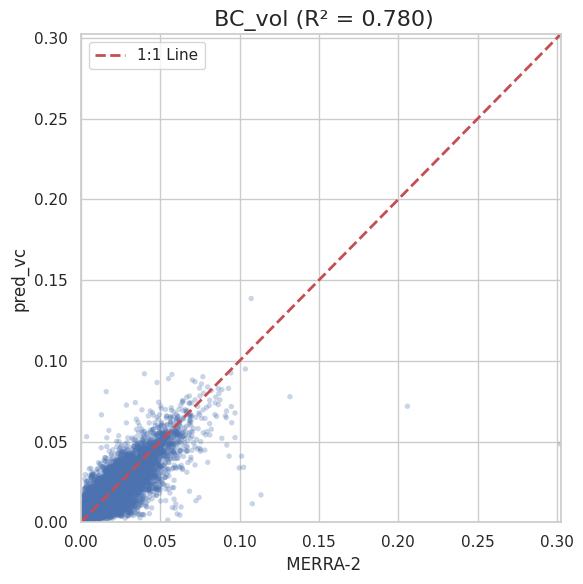

  Urban_vol: R² = 0.7676, RMSE = 0.0030


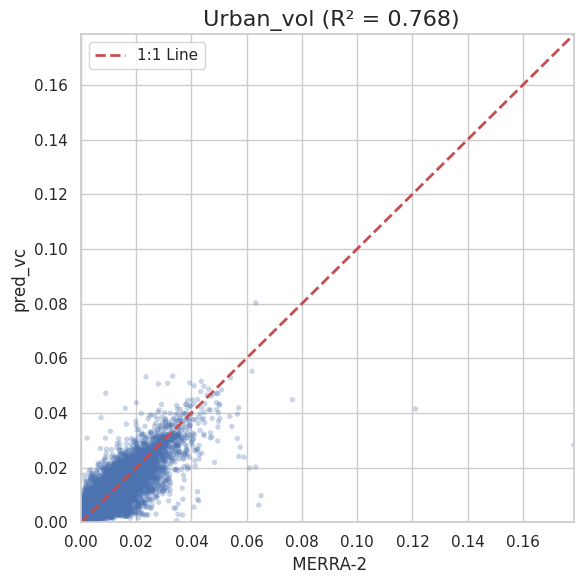

  SeaSalt_vol: R² = 0.6981, RMSE = 0.0042


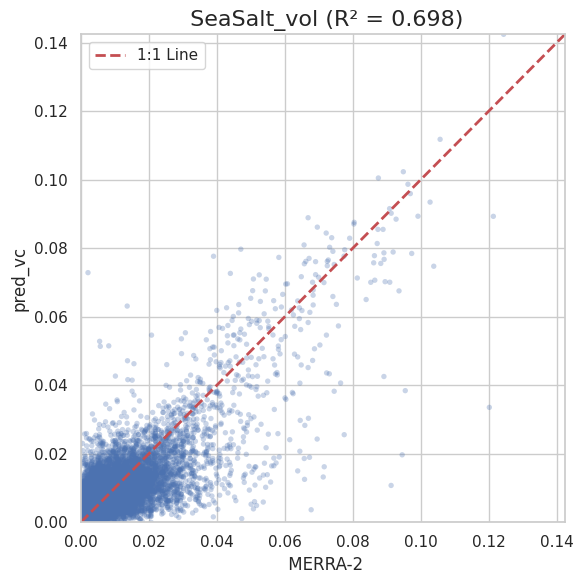

  Dust_vol: R² = 0.7493, RMSE = 0.0386


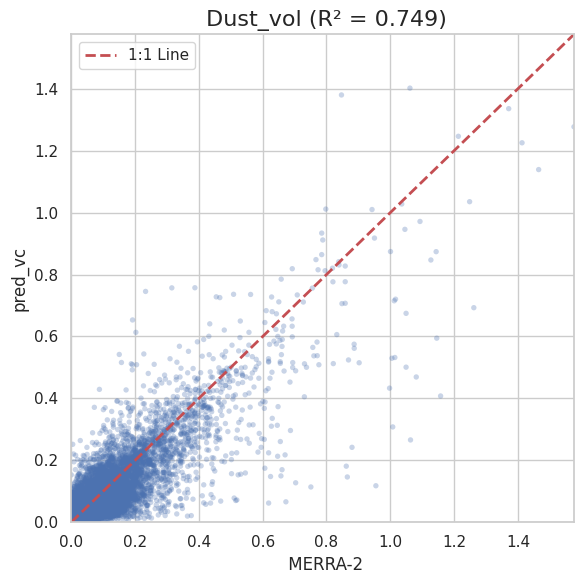

In [3]:
# --- 导入必要的库 ---
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. 定义与训练时结构完全相同的模型类
# ==============================================================================
class ResidualDNN(nn.Module):
    # (您的ResidualDNN类定义，确保与训练时完全相同)
    def __init__(self, input_dim, output_dim, layers_config=[256, 128, 64],
                 dropout_rate=0.2, l2_regularization=1e-4):
        super(ResidualDNN, self).__init__()
        layers_list = []; current_dim = input_dim
        for i, units in enumerate(layers_config):
            block = nn.Sequential(nn.Linear(current_dim, units), nn.LayerNorm(units), nn.LeakyReLU(0.2), nn.Dropout(dropout_rate))
            layers_list.append(block)
            is_residual = (i != 0 and current_dim == units)
            layers_list.append(is_residual)
            current_dim = units
        self.hidden_layers = nn.ModuleList([layer for layer in layers_list if isinstance(layer, nn.Module)])
        self.residual_flags = [flag for flag in layers_list if isinstance(flag, bool)]
        self.output_layer = nn.Linear(current_dim, output_dim)
    def forward(self, x):
        for i, layer in enumerate(self.hidden_layers):
            x_prev_layer = x; x = layer(x)
            if self.residual_flags[i]: x = x + x_prev_layer
        x = self.output_layer(x); return x

# ==============================================================================
# 2. 加载所有必需的模型和Scalers
# ==============================================================================
print(f"\n{'='*20} 准备阶段：加载所有模型和Scalers {'='*20}")
device = torch.device("cpu")


input_dim_aod = 133


# --- B. 加载您刚刚训练的模型 (我们称之为VC模型) ---
VC_MODEL_PATH = '/media/amers/SSD_part1/whx/ResNet_forDPC/dynamic_prior/vc_model_DPC.pth'
SCALER_X_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forDPC/dynamic_prior/dnn_feature_scaler_vc_DPC.joblib'
SCALER_Y_VC_PATH = '/media/amers/SSD_part1/whx/ResNet_forDPC/dynamic_prior/dnn_target_scaler_vc_DPC.joblib'
input_dim_vc = input_dim_aod 
output_dim_vc = 4
vc_model = ResidualDNN(input_dim_vc, output_dim_vc, layers_config=[1024, 512, 256, 128]).to(device)
vc_model.load_state_dict(torch.load(VC_MODEL_PATH, map_location=device))
vc_model.eval()
scaler_x_vc = joblib.load(SCALER_X_VC_PATH)
scaler_y_vc = joblib.load(SCALER_Y_VC_PATH)
print("体积浓度(VC)模型及相关Scalers加载成功！")

# ==============================================================================
# 3. 加载并准备MERRA2测试数据
# ==============================================================================
try:
    data_raw = pd.read_csv('/media/amers/SSD_part1/whx/ResNet_forDPC/dynamic_prior/DPC_prior_dataset.csv')
    data = data_raw.sample(frac=1, random_state=42).reset_index(drop=True)
except FileNotFoundError:
    print("错误：找不到MERRA-2匹配数据集！"); exit()

# --- 准备特征和目标 ---
component_columns = ['BC_vol', 'Urban_vol', 'SeaSalt_vol', 'Dust_vol']
ordered_feature_columns = []
base_features = ['elev']
ordered_feature_columns.extend(base_features)
obs_sequence = ['sza', 'vza', 'phi', 'TOA443', 'TOA490', 'DolP490', 'TOA565', 'TOA670', 'DolP670', 'TOA865', 'DolP865']
for i in range(2, 14):
    for name in obs_sequence:
        ordered_feature_columns.append(f'{name}_ang{i}')

data['BC_vol'] = data['BC_vol'] + data['Urban_vol'] * 0.6
data['Urban_vol'] = data['Urban_vol']* 0.4
y_fractions = data[component_columns].values
X_base = data[ordered_feature_columns]
y_true_vc = data[component_columns]

# --- 划分数据集，确保使用与训练时完全相同的测试集 ---
_, X_temp, _, y_temp = train_test_split(X_base, y_true_vc, test_size=0.2, random_state=42)
_, X_test_base, _, y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
print(f"\n已准备 {len(X_test_base)} 条测试样本进行验证。")

# ==============================================================================
# 4. 执行预测流水线
# ==============================================================================
print("\n--- 开始执行预测流水线 ---")



# --- Step 2: 构建VC模型的输入 ---
X_test_for_vc = X_test_base.values

# --- Step 3: 使用VC模型预测体积浓度 ---
X_test_scaled_for_vc = scaler_x_vc.transform(X_test_for_vc)
X_test_tensor_vc = torch.from_numpy(X_test_scaled_for_vc).float().to(device)
with torch.no_grad():
    predicted_vc_scaled = vc_model(X_test_tensor_vc).cpu().numpy()
predicted_vc = scaler_y_vc.inverse_transform(predicted_vc_scaled)
predicted_vc[predicted_vc < 0] = 0 # 确保物理合理性

y_pred_df = pd.DataFrame(predicted_vc, columns=component_columns, index=y_test.index)
print("预测完成！")

# ==============================================================================
# 5. 评估与可视化 (简单散点图)
# ==============================================================================
print("\n--- 在测试集上的评估结果 ---")
sns.set_theme(style="whitegrid")

for target in component_columns:
    true_values = y_test[target]
    pred_values = y_pred_df[target]
    
    r2 = r2_score(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    
    print(f"  {target}: R² = {r2:.4f}, RMSE = {rmse:.4f}")
    
    # --- 绘制简单散点图 ---
    plt.figure(figsize=(6, 6))
    plt.scatter(true_values, pred_values, alpha=0.3, s=15, edgecolor='none')
    
    # 添加1:1线
    lims = [
        min(true_values.min(), pred_values.min()),
        max(true_values.max(), pred_values.max())
    ]
    plt.plot(lims, lims, 'r--', linewidth=2, label='1:1 Line')
    
    plt.title(f' {target} (R² = {r2:.3f})', fontsize=16)
    plt.xlabel(' MERRA-2', fontsize=12)
    plt.ylabel('pred_vc', fontsize=12)
    plt.xlim(lims)
    plt.ylim(lims)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


--- 在测试集上的评估结果 (Publication Style with 2D Histogram) ---
  BC_vol: R = 0.9399, RMSE = 0.0024, MAE = 0.0010, MBE = -0.0000


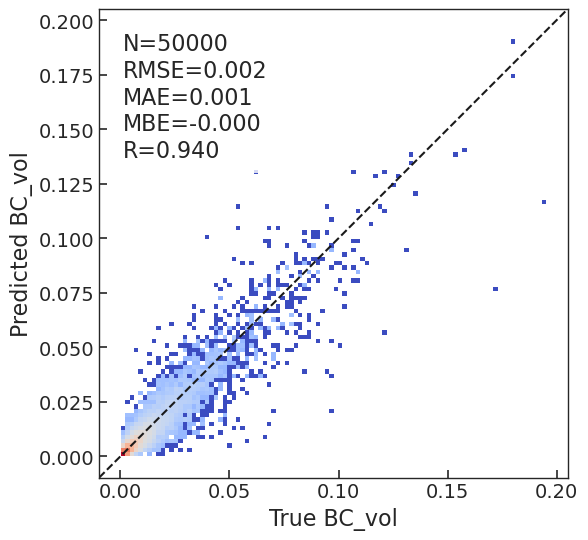

  Urban_vol: R = 0.9212, RMSE = 0.0013, MAE = 0.0007, MBE = -0.0000


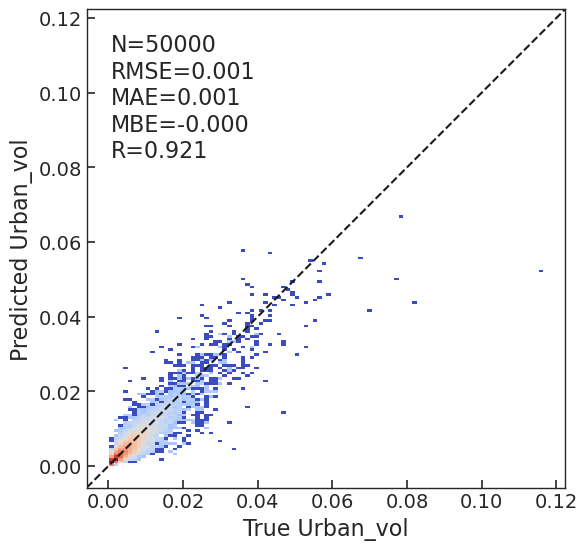

  SeaSalt_vol: R = 0.8631, RMSE = 0.0030, MAE = 0.0017, MBE = -0.0001


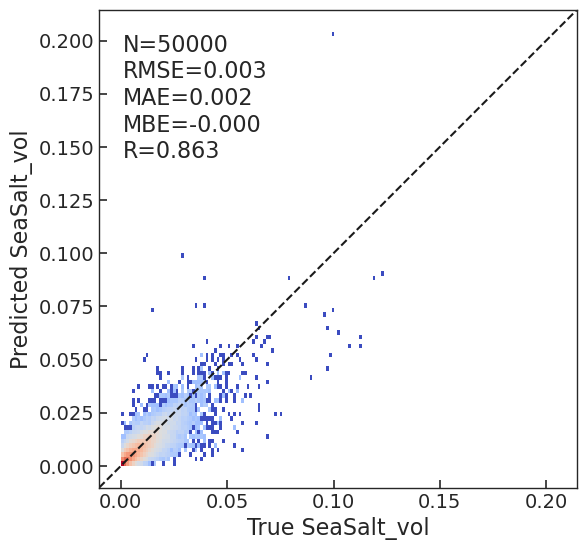

  Dust_vol: R = 0.9359, RMSE = 0.0360, MAE = 0.0167, MBE = -0.0003


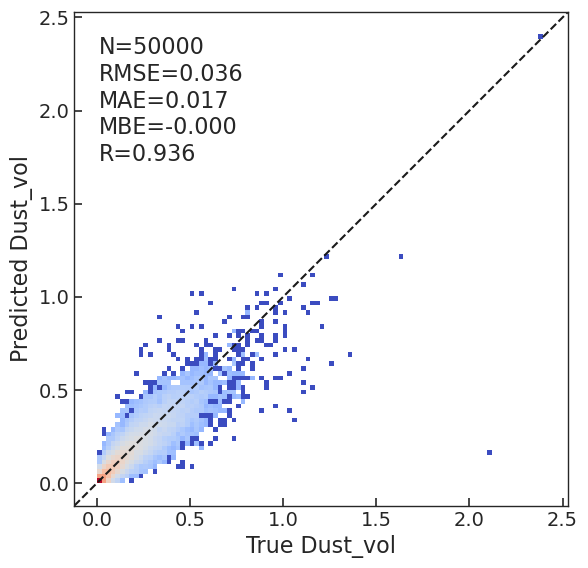

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm # 核心：导入对数色标
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import os

# --- 1. 设置全局绘图参数 ---
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# --- 示例数据 (如果需要独立运行，请取消下面的注释) ---
# from sklearn.datasets import make_regression
# X, y = make_regression(n_samples=500000, n_features=1, noise=0.8, random_state=42)
# y_test = pd.DataFrame({'AOT': y**2}) # Create a non-linear distribution
# y_pred_df = pd.DataFrame({'AOT': y**2 + np.random.normal(0, 0.5, y.shape)})
# component_columns = ['AOT']
# plot_path = './'
# --- 结束示例数据 ---

# --- 假设您的 y_test, y_pred_df, component_columns 已定义 ---
# y_test = ...
# y_pred_df = ...
# component_columns = ...

print("\n--- 在测试集上的评估结果 (Publication Style with 2D Histogram) ---")

for target in component_columns:
    true_values = y_test[target]
    pred_values = y_pred_df[target]
    
    # --- 计算评估指标 ---
    r = np.corrcoef(true_values, pred_values)[0, 1]
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    mae = mean_absolute_error(true_values, pred_values)
    N = len(true_values)
    # 计算 MBE (Mean Bias Error)
    mbe = np.mean(pred_values - true_values)
    
    print(f"  {target}: R = {r:.4f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}, MBE = {mbe:.4f}")
    
    # --- 创建图窗和坐标轴 ---
    fig, ax = plt.subplots(figsize=(6, 6))

    # --- 核心升级: 使用 plt.hist2d 代替 scatter ---
    # bins: 设置网格数量，值越大，方块越小
    # norm=LogNorm(): 使用对数色标来处理密度差异大的情况
    # cmap: 设置颜色主题
    # cmin=1: 只对包含至少一个数据点的格子着色
    from matplotlib.colors import PowerNorm 
    counts, _, _ = np.histogram2d(true_values, pred_values, bins=150)
    
    # 2. 确定颜色的上限为你非零计数的99.5百分位数
    # 这可以有效忽略极端高密度点，让颜色更好地分布
    vmax_val = np.percentile(counts[counts > 0], 99.5) 
    h = ax.hist2d(true_values, pred_values, 
                  bins=96,          # 调整这个值来改变方块大小
                  #vmax=400,
                  norm=PowerNorm(gamma=0.12), 
                  cmap='coolwarm',       # 'Blues' or 'BuPu' 是很好的选择
                  cmin=1)            # 只为非空格子上色
    
    # --- 绘制1:1线和线性拟合线 ---
    lim_min = min(true_values.min(), pred_values.min())
    lim_max = max(true_values.max(), pred_values.max())
    padding = (lim_max - lim_min) * 0.05 
    ax_lims = [lim_min - padding, lim_max + padding]
    
    ax.plot(ax_lims, ax_lims, 'k--', linewidth=1.5, label='1:1 Line') 
    
    # 注意：拟合线在密度图上可能不那么清晰，可以选择性移除或改变颜色
    # k, b = np.polyfit(true_values, pred_values, 1)
    # fit_label = f'Fit: y = {k:.2f}x + {b:.3f}'
    # ax.plot(np.array(ax_lims), np.poly1d([k, b])(np.array(ax_lims)), color='darkorange', ls='-', linewidth=2, label=fit_label)
    
    # --- 设置坐标轴和标题 ---
    ax.set_xlim(ax_lims)
    ax.set_ylim(ax_lims)
    ax.set_xlabel(f'True {target}', fontsize=16)
    ax.set_ylabel(f'Predicted {target}', fontsize=16)
    ax.set_aspect('equal', adjustable='box')
    
    # --- 设置内向刻度线和完整的黑色边框  左边和下边 ---

    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14, top=False, right=False)

    # --- 添加指标文本框 ---
    stats_text = (f'N=50000\n'
                  f'RMSE={rmse:.3f}\n'
                  f'MAE={mae:.3f}\n'
                  f'MBE={mbe:.3f}\n'
                  f'R={r:.3f}')
                  
    ax.text(0.05, 0.95, stats_text, 
            transform=ax.transAxes, 
            fontsize=16,
            verticalalignment='top', 
            fontfamily='sans-serif', # 使用无衬线字体以匹配图片
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='none', alpha=0.8))
    

    # --- 不显示图例，因为拟合线可能被隐藏 ---
    # ax.legend(loc='lower right', fontsize=14)
    
    plt.tight_layout()
    
    # --- 保存为高分辨率文件 ---
    plot_path = '/media/amers/SSD_part1/whx/ResNet_code/dynamic_prior/plot'
    if not os.path.exists(plot_path):
        os.makedirs(plot_path)
    plt.savefig(os.path.join(plot_path, f'{target}_validation_hist2d.png'), dpi=300, bbox_inches='tight')
    
    plt.show()